# Assignment 4


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from prophet import Prophet
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay

cwd = Path.cwd()

if (cwd / 'joel' / 'dat_train1.csv').exists():
    JOEL_DIR = cwd / 'joel'
elif (cwd / 'dat_train1.csv').exists():
    JOEL_DIR = cwd
elif (cwd.parent / 'dat_train1.csv').exists():
    JOEL_DIR = cwd.parent
else:
    raise FileNotFoundError('Could not find the joel data folder from the current working directory.')

if str(JOEL_DIR) not in sys.path:
    sys.path.insert(0, str(JOEL_DIR))

from model_open_journeys import build_features, make_training_snapshots

train_path = JOEL_DIR / 'dat_train1.csv'
open_path = JOEL_DIR / 'open_journeys1_flattened_all0.csv'
submission_dir = JOEL_DIR / 'kaggle_sumissions' / 'submission1'
prediction_path = submission_dir / 'open_journey_predictions.csv'
submission_path = submission_dir / 'submission.csv'
assignment_dir = JOEL_DIR / 'assignment4'
assignment_dir.mkdir(exist_ok=True)

ice_plot_path = assignment_dir / 'assignment4_ice_plot.png'
pdp_plot_path = assignment_dir / 'assignment4_pdp_plot.png'
cp_plot_path = assignment_dir / 'assignment4_cp_profiles.png'
forecast_plot_path = assignment_dir / 'assignment4_orders_forecast.png'
dropout_plot_path = assignment_dir / 'assignment4_dropout_events.png'
probability_submission_path = assignment_dir / 'assignment4_probability_submission.csv'

print('JOEL_DIR:', JOEL_DIR)


JOEL_DIR: /Users/joelyoon/Documents/git_repo/m148-project/joel


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Task 1

For the ICE plot, PDP plot, and CP profiles, I used `n_place_downpayment` when available because it was one of the more important variables in the random forest from the previous assignment. If that variable is not available in the sampled training data, the code automatically uses the most important variable from the fitted model.


In [3]:
df_task1 = pd.read_csv(
    train_path,
    usecols=['id', 'event_name', 'event_timestamp'],
    parse_dates=['event_timestamp'],
    nrows=300000,
)

df_task1 = df_task1.drop_duplicates(subset=['id', 'event_name', 'event_timestamp']).copy()
df_task1['event_timestamp'] = pd.to_datetime(df_task1['event_timestamp'], utc=True)

X_task1, y_task1, cutoff_date = make_training_snapshots(df_task1, max_training_rows=20000)

rf_task1 = RandomForestClassifier(
    n_estimators=150,
    min_samples_leaf=10,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)
rf_task1.fit(X_task1, y_task1)

importances_task1 = pd.Series(rf_task1.feature_importances_, index=X_task1.columns).sort_values(ascending=False)

if 'n_place_downpayment' in X_task1.columns and X_task1['n_place_downpayment'].nunique() > 1:
    important_variable = 'n_place_downpayment'
else:
    important_variable = importances_task1.index[0]

print('Open-window cutoff date:', cutoff_date)
print('Training rows:', len(X_task1))
print('Variable used:', important_variable)
print('Top variables:')
print(importances_task1.head(10))


Open-window cutoff date: 2022-11-24 11:26:26+00:00
Training rows: 5598
Variable used: n_place_downpayment
Top variables:
n_place_downpayment          0.340141
n_place_order_web            0.270775
n_unique_events              0.187981
journey_duration_days        0.051085
n_begin_checkout             0.033378
n_place_order_phone          0.022775
last_is_promotion_created    0.016227
n_add_to_cart                0.015793
n_view_cart                  0.015259
n_promotion_created          0.013167
dtype: float64


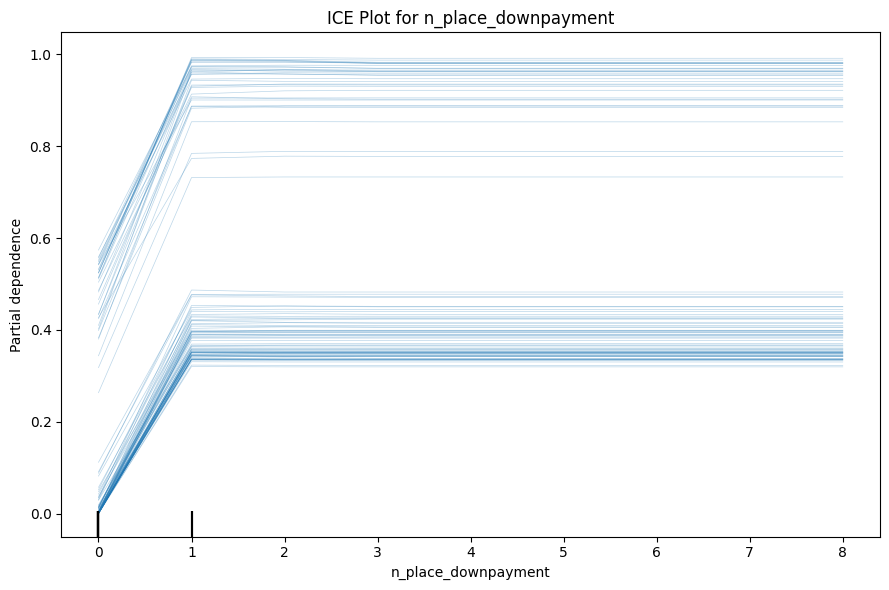

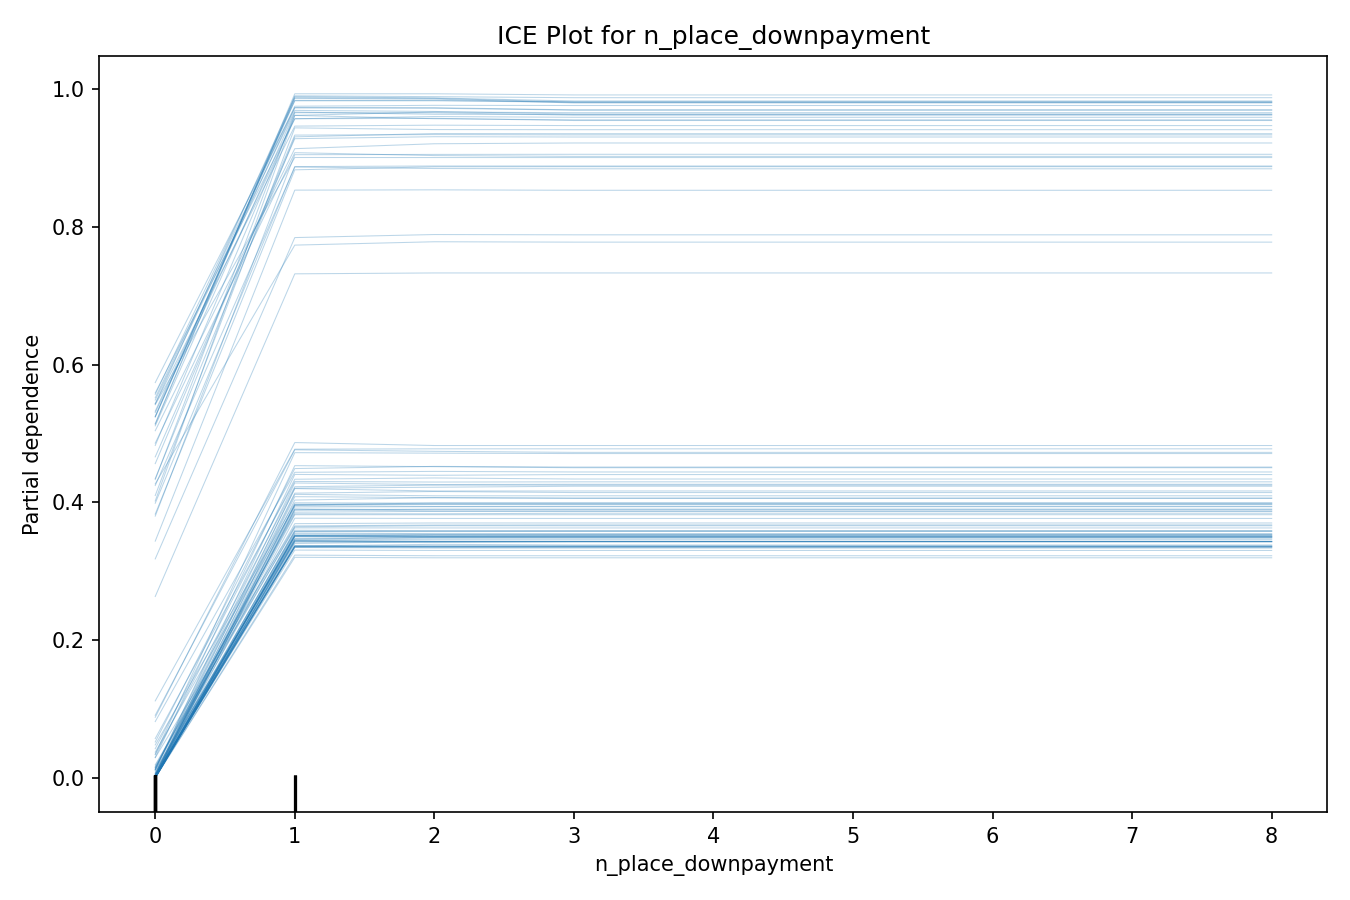

In [4]:
plot_sample = X_task1.sample(n=min(1000, len(X_task1)), random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
PartialDependenceDisplay.from_estimator(
    rf_task1,
    plot_sample,
    [important_variable],
    kind='individual',
    subsample=min(100, len(plot_sample)),
    random_state=42,
    ax=ax,
)
ax.set_title(f'ICE Plot for {important_variable}')
plt.tight_layout()
plt.savefig(ice_plot_path, dpi=150)
plt.show()

display(Image(filename=str(ice_plot_path)))


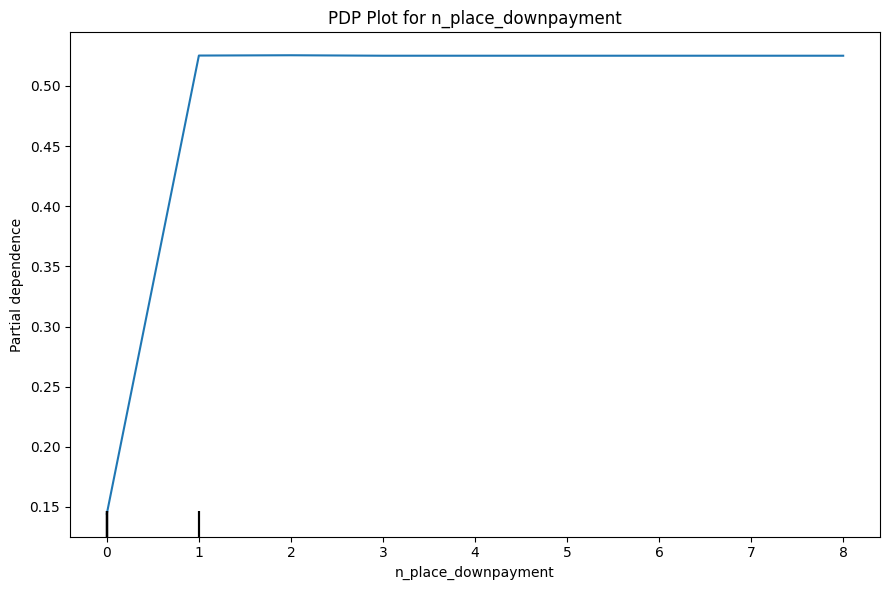

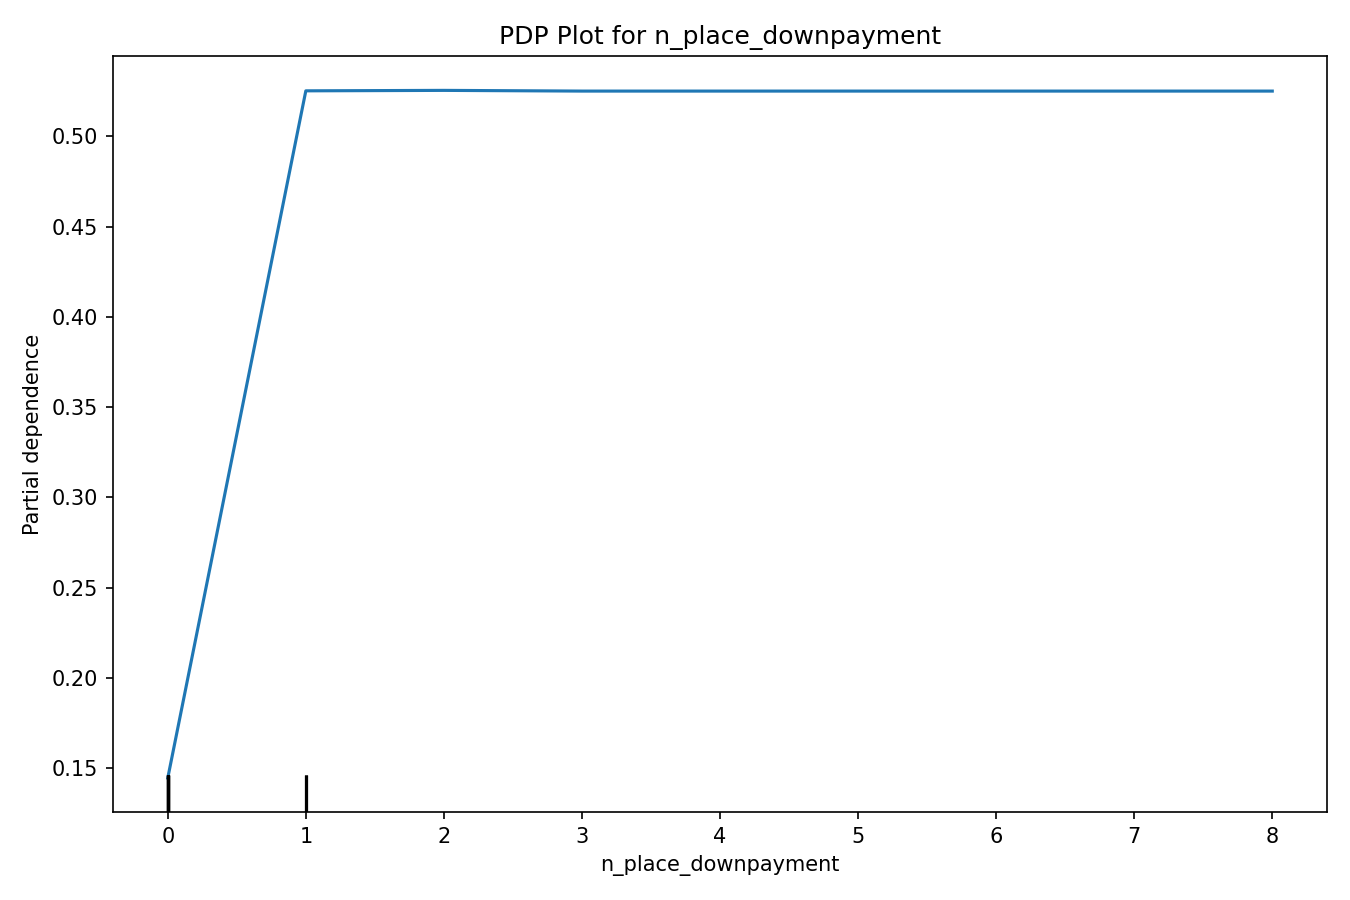

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
PartialDependenceDisplay.from_estimator(
    rf_task1,
    plot_sample,
    [important_variable],
    kind='average',
    ax=ax,
)
ax.set_title(f'PDP Plot for {important_variable}')
plt.tight_layout()
plt.savefig(pdp_plot_path, dpi=150)
plt.show()

display(Image(filename=str(pdp_plot_path)))


Report and interpretation: the ICE plot shows how the prediction changes for individual journeys when only the selected variable is changed. The PDP averages those individual curves into one overall relationship. If the PDP rises as `n_place_downpayment` increases, then downpayment activity is a positive signal for eventual shipment. The ICE plot is still important because it shows whether that effect is consistent across journeys or whether it depends strongly on the other journey features.


### CP profiles

The CP profiles below choose one incomplete journey with a high predicted probability of success and one with a low predicted probability of success. For each journey, I hold all other features fixed and vary the selected variable. This gives a local explanation for those specific journeys instead of the average explanation from the PDP.


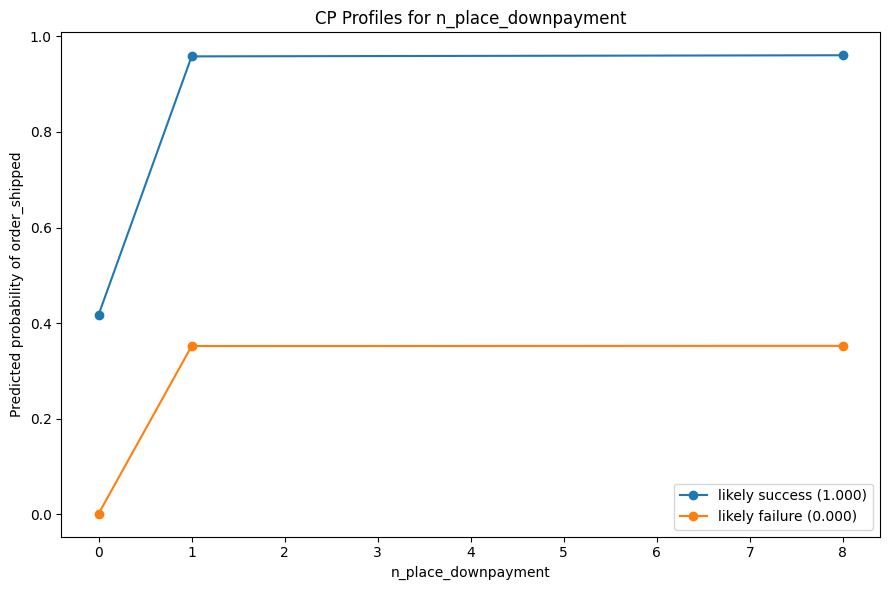

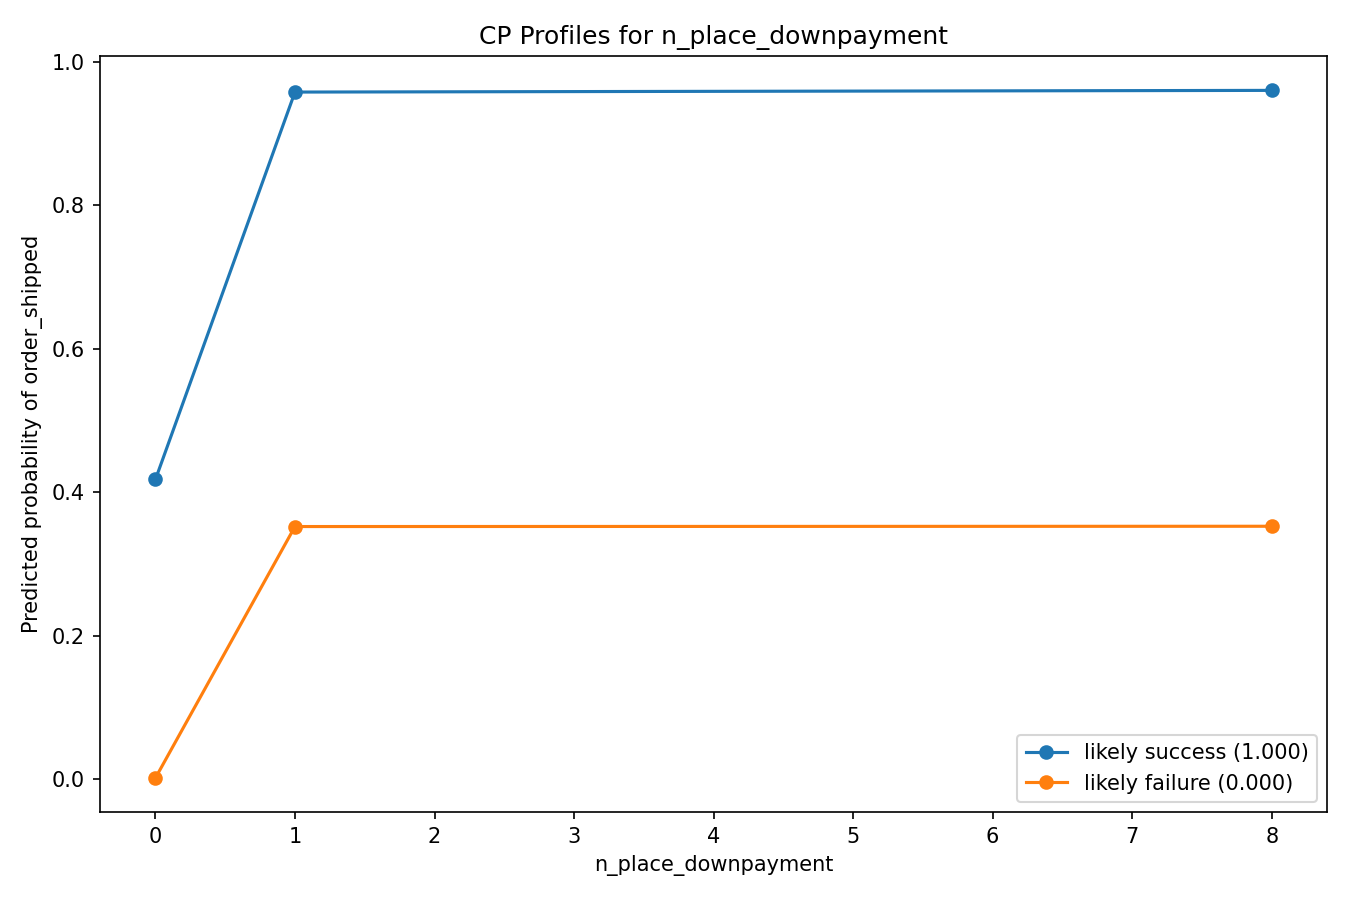

,id,profile,n_place_downpayment,ship_probability
0,-1160764510 193263322,likely success (1.000),0.0,0.417774
1,-1160764510 193263322,likely success (1.000),1.0,0.958240
2,-1160764510 193263322,likely success (1.000),8.0,0.960595
3,479602812 -1297585656,likely failure (0.000),0.0,0.001271
4,479602812 -1297585656,likely failure (0.000),1.0,0.352074
5,479602812 -1297585656,likely failure (0.000),8.0,0.352477


In [6]:
predictions = pd.read_csv(prediction_path)
prob_col = 'ship_probability' if 'ship_probability' in predictions.columns else 'order_shipped'

success_row = predictions.sort_values(prob_col, ascending=False).iloc[0]
failure_row = predictions.sort_values(prob_col, ascending=True).iloc[0]
profile_ids = [success_row['id'], failure_row['id']]
profile_labels = [
    f"likely success ({success_row[prob_col]:.3f})",
    f"likely failure ({failure_row[prob_col]:.3f})",
]

profile_events = []
for chunk in pd.read_csv(
    train_path,
    usecols=['id', 'event_name', 'event_timestamp'],
    parse_dates=['event_timestamp'],
    chunksize=500000,
):
    selected = chunk[chunk['id'].isin(profile_ids)]
    if len(selected):
        profile_events.append(selected)

profile_events = pd.concat(profile_events, ignore_index=True)
profile_events['event_timestamp'] = pd.to_datetime(profile_events['event_timestamp'], utc=True)
X_profiles = build_features(profile_events).reindex(profile_ids).reindex(columns=X_task1.columns, fill_value=0).fillna(0)

values = np.unique(np.quantile(plot_sample[important_variable], np.linspace(0, 1, 8))).astype(float)
if len(values) < 2:
    values = np.arange(0, max(2, int(plot_sample[important_variable].max()) + 2), dtype=float)

fig, ax = plt.subplots(figsize=(9, 6))
cp_rows = []
for journey_id, label in zip(profile_ids, profile_labels):
    repeated = pd.DataFrame([X_profiles.loc[journey_id].to_dict()] * len(values))
    repeated[important_variable] = values
    probs = rf_task1.predict_proba(repeated[X_task1.columns])[:, 1]
    ax.plot(values, probs, marker='o', label=label)
    for value, prob in zip(values, probs):
        cp_rows.append({'id': journey_id, 'profile': label, important_variable: value, 'ship_probability': prob})

ax.set_xlabel(important_variable)
ax.set_ylabel('Predicted probability of order_shipped')
ax.set_title(f'CP Profiles for {important_variable}')
ax.legend()
plt.tight_layout()
plt.savefig(cp_plot_path, dpi=150)
plt.show()

display(Image(filename=str(cp_plot_path)))
pd.DataFrame(cp_rows)


CP interpretation: the high-probability incomplete journey starts from a stronger baseline, so even when the selected feature is set to low values, the model still sees other signals that make success plausible. The low-probability journey stays low unless the selected feature becomes large enough to offset weaker evidence elsewhere. This is the main difference between CP profiles and the PDP: the PDP gives a global average pattern, while the CP profiles explain individual journeys.


## Task 2

For the Kaggle submission, I used the model's predicted probability instead of only submitting hard 0/1 classifications. Since the competition uses Brier score, probabilities are more informative than thresholded labels.


In [7]:
predictions = pd.read_csv(prediction_path)
prob_col = 'ship_probability' if 'ship_probability' in predictions.columns else 'order_shipped'

probability_submission = predictions[['id', prob_col]].rename(columns={prob_col: 'order_shipped'}).copy()
probability_submission['order_shipped'] = probability_submission['order_shipped'].clip(0, 1)
probability_submission.to_csv(probability_submission_path, index=False)

print('Rows:', len(probability_submission))
print('Saved probability submission to:', probability_submission_path)
print('Mean predicted success probability:', probability_submission['order_shipped'].mean())
probability_submission.head()


Rows: 158325
Saved probability submission to: /Users/joelyoon/Documents/git_repo/m148-project/joel/assignment4/assignment4_probability_submission.csv
Mean predicted success probability: 0.04936239913747837


,id,order_shipped
0,-1000001271 551641434,0.008728
1,-100001164 -1710062169,0.018156
2,-1000073039 494887319,0.007499
3,-1000092799 -1963858498,0.000827
4,-100009516 1394046265,0.018115


The submitted values should be interpreted as the probability that the incomplete journey eventually ends in `order_shipped`. Most probabilities are low because many open journeys have not reached the strongest purchase-intent actions yet.


## Task 3

I computed the number of `order_shipped` events per month. For a first forecast of monthly shipments in 2024, I would use Prophet because it handles trend and yearly seasonality directly and is easy to update as more monthly data arrives. ARIMA/SARIMA would also be reasonable, especially if we spend more time diagnosing stationarity and autocorrelation.


In [8]:
monthly_parts = []

for chunk in pd.read_csv(
    train_path,
    usecols=['event_name', 'event_timestamp'],
    parse_dates=['event_timestamp'],
    chunksize=500000,
):
    shipped = chunk.loc[chunk['event_name'].eq('order_shipped'), ['event_timestamp']].copy()
    if shipped.empty:
        continue
    shipped['event_timestamp'] = pd.to_datetime(shipped['event_timestamp'], utc=True)
    monthly_parts.append(shipped.set_index('event_timestamp').resample('MS').size())

monthly_orders = pd.concat(monthly_parts, axis=1).sum(axis=1).sort_index()
monthly_orders = monthly_orders.asfreq('MS', fill_value=0).rename('orders_shipped')

monthly_orders.tail()


event_timestamp
2022-09-01 00:00:00+00:00     5108.0
2022-10-01 00:00:00+00:00     6236.0
2022-11-01 00:00:00+00:00    10119.0
2022-12-01 00:00:00+00:00    19917.0
2023-01-01 00:00:00+00:00     4752.0
Freq: MS, Name: orders_shipped, dtype: float64

11:12:32 - cmdstanpy - INFO - Chain [1] start processing
11:12:32 - cmdstanpy - INFO - Chain [1] done processing


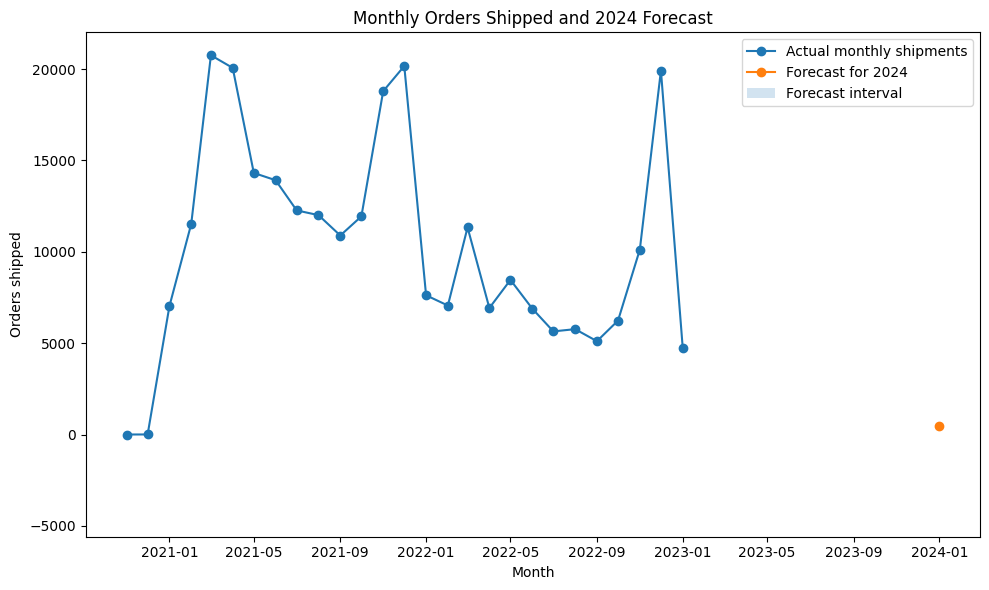

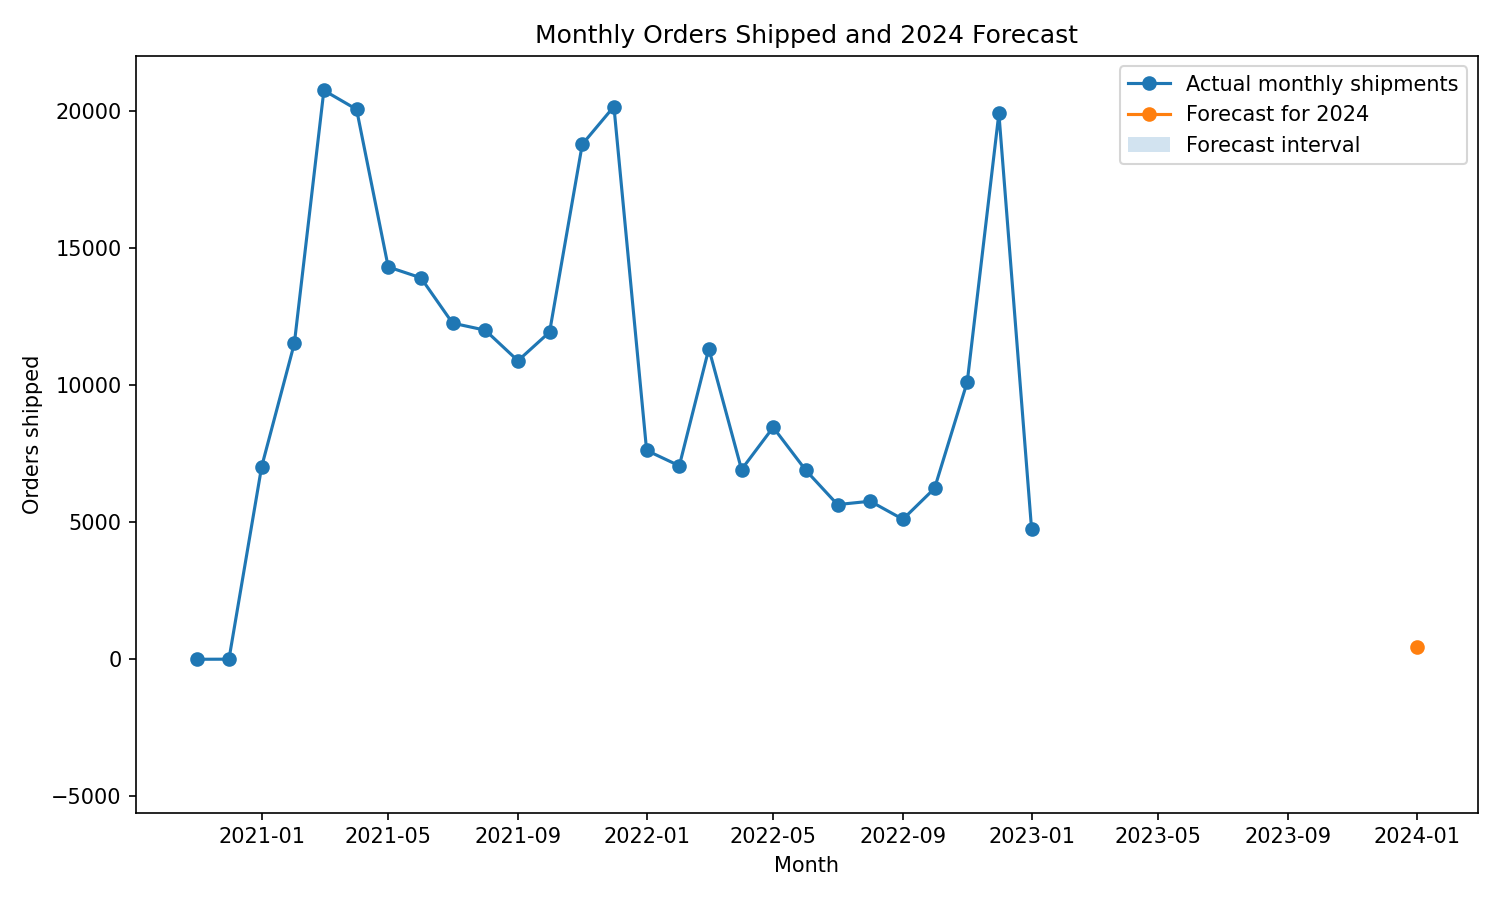

,ds,yhat,yhat_lower,yhat_upper
38,2024-01-01,440.195762,-4337.96695,4945.138772


In [9]:
prophet_df = monthly_orders.reset_index()
prophet_df.columns = ['ds', 'y']
prophet_df['ds'] = prophet_df['ds'].dt.tz_localize(None)

train_forecast_df = prophet_df[prophet_df['ds'] < '2024-01-01'].copy()

model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(train_forecast_df)

future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)
forecast_2024 = forecast[(forecast['ds'] >= '2024-01-01') & (forecast['ds'] < '2025-01-01')]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(prophet_df['ds'], prophet_df['y'], marker='o', label='Actual monthly shipments')
ax.plot(forecast_2024['ds'], forecast_2024['yhat'], marker='o', label='Forecast for 2024')
ax.fill_between(
    forecast_2024['ds'],
    forecast_2024['yhat_lower'],
    forecast_2024['yhat_upper'],
    alpha=0.2,
    label='Forecast interval',
)
ax.set_title('Monthly Orders Shipped and 2024 Forecast')
ax.set_xlabel('Month')
ax.set_ylabel('Orders shipped')
ax.legend()
plt.tight_layout()
plt.savefig(forecast_plot_path, dpi=150)
plt.show()

display(Image(filename=str(forecast_plot_path)))
forecast_2024[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]


Predictor variables that could improve the forecast include promotions, marketing campaign activity, web traffic or journey starts, checkout starts, downpayment events, seasonality indicators, and macro calendar effects. In this notebook I used only the historical shipment count, so the forecast is a baseline time-series model rather than a causal or driver-based forecast.


## Task 4

I looked more closely at where unsuccessful journeys appear to drop out. The question is: what is the last observed action for journeys that have not shipped? This is useful because it shows which stage of the journey may need better follow-up or intervention.


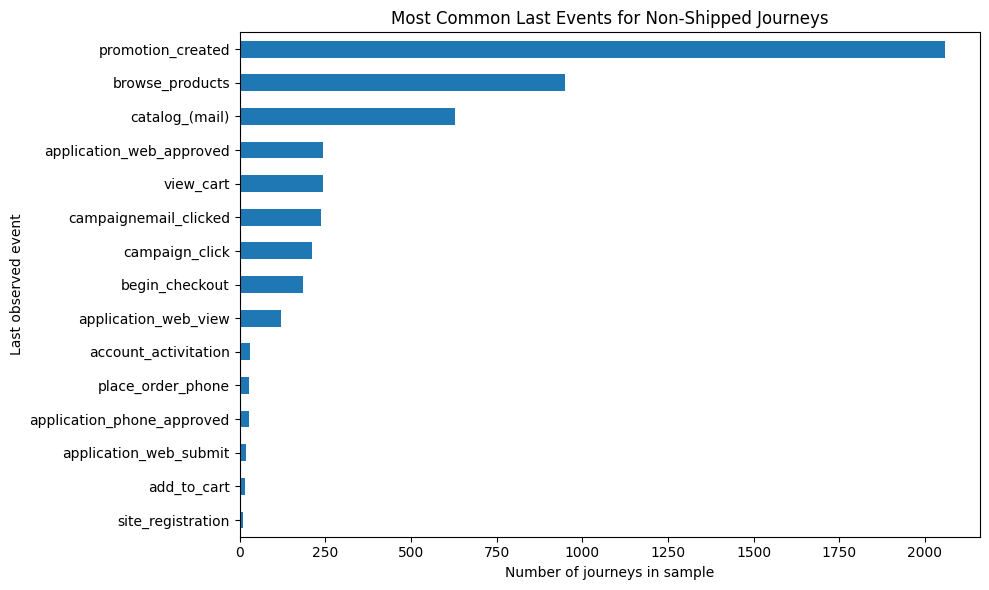

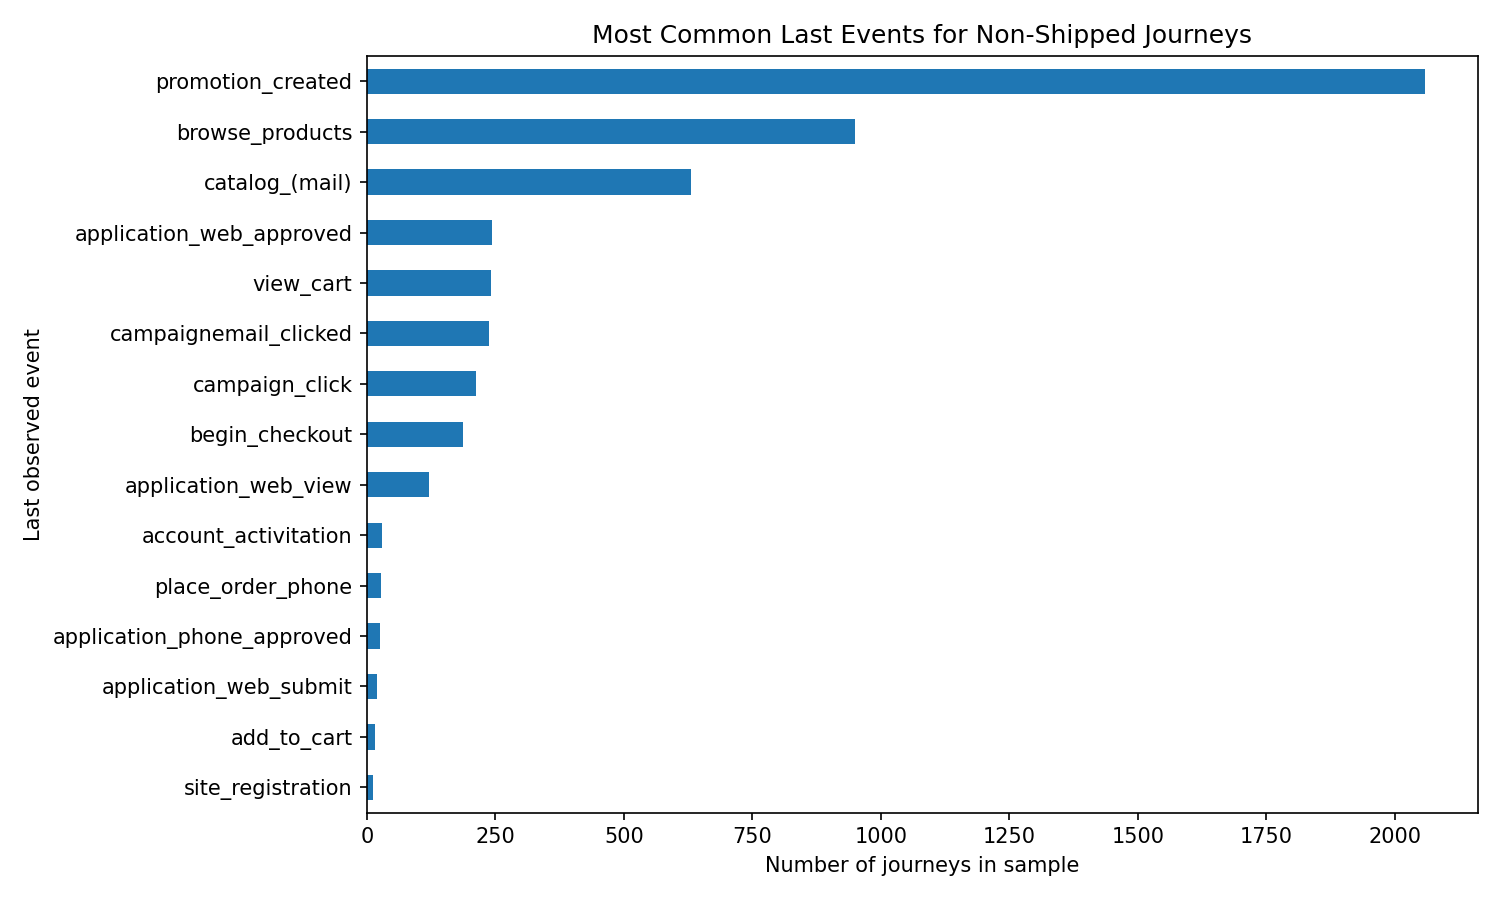

Median non-shipped journey length in days: 153.9213773148148
Median number of events in non-shipped journeys: 27.0


last_event_name
promotion_created             2058
browse_products                950
catalog_(mail)                 630
application_web_approved       244
view_cart                      242
campaignemail_clicked          237
campaign_click                 212
begin_checkout                 186
application_web_view           121
account_activitation            29
place_order_phone               27
application_phone_approved      26
application_web_submit          19
add_to_cart                     15
site_registration               11
Name: count, dtype: int64

In [10]:
journey_summary = (
    df_task1.sort_values(['id', 'event_timestamp'])
    .groupby('id')
    .agg(
        first_event_time=('event_timestamp', 'first'),
        last_event_time=('event_timestamp', 'last'),
        last_event_name=('event_name', 'last'),
        n_events=('event_name', 'size'),
        shipped=('event_name', lambda s: int((s == 'order_shipped').any())),
    )
)
journey_summary['duration_days'] = (
    journey_summary['last_event_time'] - journey_summary['first_event_time']
).dt.total_seconds() / (60 * 60 * 24)

non_shipped = journey_summary[journey_summary['shipped'].eq(0)].copy()
terminal_counts = non_shipped['last_event_name'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
terminal_counts.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Most Common Last Events for Non-Shipped Journeys')
ax.set_xlabel('Number of journeys in sample')
ax.set_ylabel('Last observed event')
plt.tight_layout()
plt.savefig(dropout_plot_path, dpi=150)
plt.show()

display(Image(filename=str(dropout_plot_path)))

print('Median non-shipped journey length in days:', non_shipped['duration_days'].median())
print('Median number of events in non-shipped journeys:', non_shipped['n_events'].median())
terminal_counts


Interpretation: this dropout view separates unsuccessful journeys by their last observed milestone. If many journeys end around browsing, cart, or checkout events, that suggests customers are dropping out before the final purchase step. If many end around application or downpayment events, then the bottleneck may be later in the purchase process. A next step would be to repeat this on the full data and compare the terminal-event distribution against successful journeys right before `order_shipped`.
